# Scenario C Dataset Generator (Robustness Framework)

This notebook creates **Scenario C** for robust training and stress testing.

Design goals:
- Keep row-level structure of your panel data.
- Generate realistic demand worlds (level shifts, trend changes, seasonality variation, promos, stockout/lead-time pressure).
- Prevent leakage in evaluation by splitting by `scenario_id`.
- Export files for direct modeling.


In [1]:
# =========================================
# BLOCK 1 — Setup and Load Base (B) Dataset
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20260312
N_SCENARIOS = 60
TEST_SCENARIOS = 15

BASE_AUG_PATH = "/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_monthly_augmented_wms_features.xlsx"
BASE_SHEET = "FG_Demand_Long_Augmented"

OUT_CSV = "/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_scenario_c_dataset.csv"
OUT_XLSX = "/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_scenario_c_dataset.xlsx"
OUT_META = "/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_scenario_c_metadata.csv"

base = pd.read_excel(BASE_AUG_PATH, sheet_name=BASE_SHEET)
base["month"] = pd.to_datetime(base["month"])
base = base.sort_values(["fg_code", "month"]).reset_index(drop=True)

required = [
    "month", "fg_code", "fg_name", "fg_category", "demand_units",
    "on_hand_inventory", "stockout_days", "promotion_flag", "price_or_discount",
    "lead_time_days", "supplier_otif", "inbound_po_qty", "open_sales_orders",
    "returns_qty", "holiday_flag"
]
missing = [c for c in required if c not in base.columns]
if missing:
    raise ValueError(f"Missing required columns in augmented base: {missing}")

print("Base shape:", base.shape)
print("Date range:", base["month"].min().date(), "to", base["month"].max().date())
print("SKUs:", base["fg_code"].nunique())


Base shape: (3708, 15)
Date range: 2023-02-01 to 2026-01-01
SKUs: 103


In [2]:
# =========================================
# BLOCK 2 — Scenario Engine
# =========================================

all_months = np.sort(base["month"].unique())
month_to_idx = {m: i for i, m in enumerate(all_months)}
month_idx = base["month"].map(month_to_idx).astype(int)
month_num = base["month"].dt.month

sku_median_demand = base.groupby("fg_code")["demand_units"].median()
sku_lead_median = base.groupby("fg_code")["lead_time_days"].median()

categories = sorted(base["fg_category"].dropna().unique().tolist())

scenario_frames = []
meta_rows = []

for scenario_id in range(N_SCENARIOS):
    rng = np.random.default_rng(SEED + scenario_id)
    s = base.copy()

    # Global dynamics
    level_shift = float(np.clip(rng.normal(0.0, 0.06), -0.20, 0.20))
    trend_slope = float(np.clip(rng.normal(0.0, 0.0035), -0.010, 0.010))
    season_amp = float(rng.uniform(0.85, 1.25))
    promo_scale = float(rng.uniform(0.85, 1.45))
    stockout_scale = float(rng.uniform(0.70, 1.35))
    lead_penalty = float(rng.uniform(0.002, 0.012))
    noise_scale = float(rng.uniform(0.03, 0.12))

    # Category-level effects (small but persistent)
    cat_effect = {cat: float(np.clip(rng.normal(0.0, 0.05), -0.15, 0.15)) for cat in categories}

    # Event shocks on specific months (positive or negative)
    event_effect = pd.Series(1.0, index=all_months)
    n_events = int(rng.integers(1, 4))
    for _ in range(n_events):
        start = int(rng.integers(0, max(1, len(all_months) - 1)))
        duration = int(rng.integers(1, 4))
        impact = float(rng.uniform(-0.25, 0.35))
        end = min(len(all_months), start + duration)
        for j in range(start, end):
            event_effect.iloc[j] *= (1.0 + impact)

    # Intermittent-demand stress on a subset of SKUs
    frac_stress_skus = float(rng.uniform(0.08, 0.25))
    n_stress = max(1, int(frac_stress_skus * s["fg_code"].nunique()))
    stress_skus = set(rng.choice(s["fg_code"].unique(), size=n_stress, replace=False))
    intermittency_p = float(rng.uniform(0.06, 0.22))

    # Build demand multipliers
    seasonal = 1.0 + (season_amp - 1.0) * np.sin(2.0 * np.pi * (month_num / 12.0))
    macro = 1.0 + level_shift + trend_slope * month_idx
    cat_mul = 1.0 + s["fg_category"].map(cat_effect).fillna(0.0)
    event_mul = s["month"].map(event_effect)

    promo_mul = 1.0 + s["promotion_flag"] * promo_scale * (0.05 + 0.55 * s["price_or_discount"])
    stockout_mul = 1.0 - stockout_scale * np.minimum(s["stockout_days"] / 31.0, 0.40)

    lead_over = (s["lead_time_days"] - s["fg_code"].map(sku_lead_median)).clip(lower=0)
    lead_mul = 1.0 - lead_penalty * lead_over

    otif_center = float(s["supplier_otif"].mean())
    otif_mul = 1.0 + 0.35 * (s["supplier_otif"] - otif_center)

    eps = rng.normal(0.0, noise_scale, size=len(s))

    demand_sim = (
        s["demand_units"].astype(float)
        * macro
        * seasonal
        * cat_mul
        * event_mul
        * promo_mul
        * stockout_mul
        * lead_mul
        * otif_mul
        * (1.0 + eps)
    )

    # Intermittency injection: only for stressed SKUs on low-demand months
    stress_mask = s["fg_code"].isin(stress_skus)
    low_mask = s["demand_units"] <= s["fg_code"].map(sku_median_demand)
    zero_inject = rng.uniform(0, 1, size=len(s)) < intermittency_p
    demand_sim = np.where(stress_mask & low_mask & zero_inject, 0.0, demand_sim)

    demand_sim = np.clip(np.round(demand_sim), 0, None).astype(int)

    # Simulate operational covariates coherently with new demand
    # On-hand responds partially (not fully) to new demand to mimic planning lag.
    on_hand_sim = s["on_hand_inventory"].astype(float) * (0.88 + 0.35 * np.clip(macro, 0.7, 1.4))
    on_hand_sim *= (1.0 + rng.normal(0, 0.05, size=len(s)))
    on_hand_sim = np.clip(np.round(on_hand_sim), 0, None).astype(int)

    inbound_sim = s["inbound_po_qty"].astype(float) * (0.90 + 0.40 * np.clip(macro, 0.7, 1.5))
    inbound_sim += np.maximum(demand_sim - on_hand_sim, 0) * rng.uniform(0.10, 0.35, size=len(s))
    inbound_sim = np.clip(np.round(inbound_sim), 0, None).astype(int)

    cover_ratio = (on_hand_sim + 0.5 * inbound_sim) / (np.maximum(demand_sim, 1))
    stockout_sim = s["stockout_days"].astype(float) + (cover_ratio < 0.9).astype(float) * rng.uniform(0.8, 3.5, size=len(s))
    stockout_sim += (event_mul.values < 0.9).astype(float) * rng.uniform(0.2, 1.5, size=len(s))
    stockout_sim = np.clip(np.round(stockout_sim), 0, 20).astype(int)

    lead_sim = s["lead_time_days"].astype(float) * (1.0 + (event_mul.values < 0.9).astype(float) * rng.uniform(0.03, 0.20))
    lead_sim += rng.normal(0, 1.5, size=len(s))
    lead_sim = np.clip(np.round(lead_sim), 5, 120).astype(int)

    otif_sim = s["supplier_otif"].astype(float) - 0.0025 * np.maximum(lead_sim - s["lead_time_days"].values, 0)
    otif_sim -= 0.010 * (stockout_sim > s["stockout_days"].values).astype(float)
    otif_sim += rng.normal(0, 0.008, size=len(s))
    otif_sim = np.clip(otif_sim, 0.70, 0.995).round(4)

    oso_sim = np.clip(np.round(demand_sim * (0.10 + 0.22 * rng.uniform(0, 1, size=len(s)))), 0, None).astype(int)
    ret_sim = np.clip(np.round(np.maximum(demand_sim, 0) * (0.008 + 0.03 * rng.uniform(0, 1, size=len(s)))), 0, None).astype(int)

    s["scenario_id"] = scenario_id
    s["demand_units"] = demand_sim
    s["on_hand_inventory"] = on_hand_sim
    s["stockout_days"] = stockout_sim
    s["lead_time_days"] = lead_sim
    s["supplier_otif"] = otif_sim
    s["inbound_po_qty"] = inbound_sim
    s["open_sales_orders"] = oso_sim
    s["returns_qty"] = ret_sim

    scenario_frames.append(s)

    meta_rows.append({
        "scenario_id": scenario_id,
        "level_shift": level_shift,
        "trend_slope": trend_slope,
        "season_amp": season_amp,
        "promo_scale": promo_scale,
        "stockout_scale": stockout_scale,
        "lead_penalty": lead_penalty,
        "noise_scale": noise_scale,
        "n_events": n_events,
        "stressed_skus": n_stress,
        "intermittency_p": intermittency_p,
    })

c_df = pd.concat(scenario_frames, ignore_index=True)
meta_df = pd.DataFrame(meta_rows)

print("Scenario C shape:", c_df.shape)
print("Unique scenarios:", c_df["scenario_id"].nunique())
print("Demand min/max:", int(c_df["demand_units"].min()), int(c_df["demand_units"].max()))


Scenario C shape: (222480, 16)
Unique scenarios: 60
Demand min/max: 0 197693


In [3]:
# =========================================
# BLOCK 3 — Train/Test Split by Scenario ID
# =========================================

rng_split = np.random.default_rng(SEED)
all_ids = np.arange(N_SCENARIOS)
test_ids = np.sort(rng_split.choice(all_ids, size=TEST_SCENARIOS, replace=False))
train_ids = np.array([x for x in all_ids if x not in set(test_ids)])

c_df["scenario_split"] = np.where(c_df["scenario_id"].isin(test_ids), "test", "train")
meta_df["scenario_split"] = np.where(meta_df["scenario_id"].isin(test_ids), "test", "train")

print("Train scenarios:", len(train_ids), train_ids[:10], "...")
print("Test scenarios:", len(test_ids), test_ids)
print("Rows by split:")
print(c_df["scenario_split"].value_counts())


Train scenarios: 45 [ 0  1  2  3  4  6  7  8  9 11] ...
Test scenarios: 15 [ 5 10 14 15 19 25 26 27 32 34 35 40 41 49 50]
Rows by split:
scenario_split
train    166860
test      55620
Name: count, dtype: int64


Structural QA: PASS

Base demand summary:
count      3708.00
mean      29995.53
std       18772.18
min        2266.00
10%        7047.00
50%       26956.50
90%       57840.20
max      108530.00
Name: demand_units, dtype: float64

Scenario C demand summary:
count    222480.00
mean      29988.53
std       20384.12
min           0.00
10%        6704.00
50%       26170.00
90%       58222.10
max      197693.00
Name: demand_units, dtype: float64


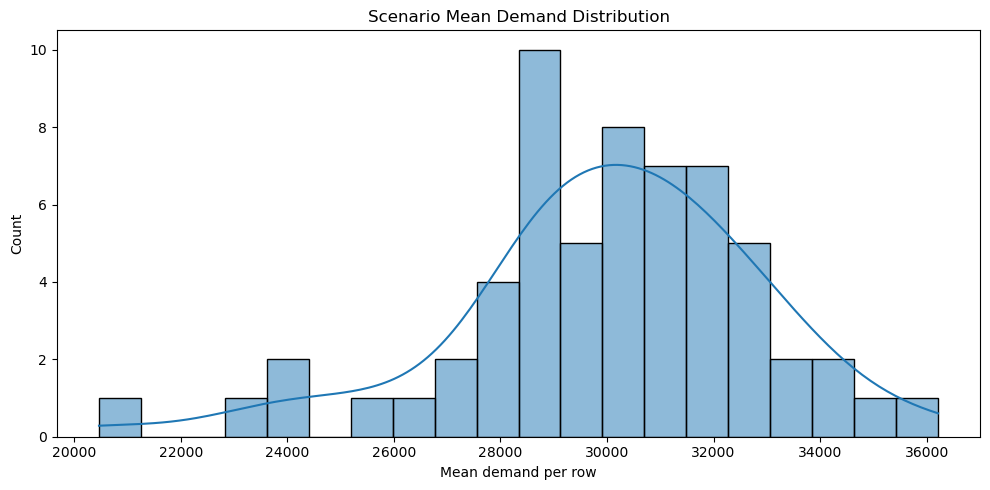

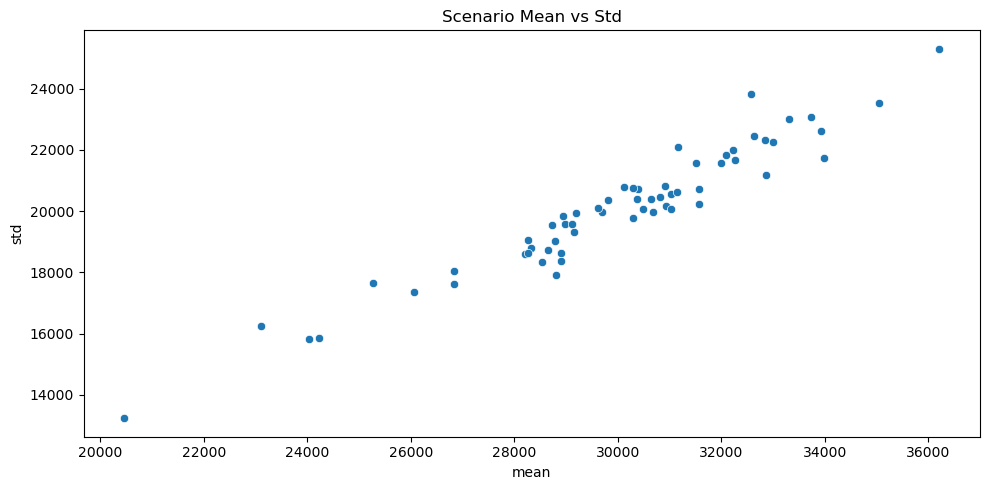

In [4]:
# =========================================
# BLOCK 4 — QA Checks and Diagnostics
# =========================================

# Structural checks
assert c_df.duplicated(["scenario_id", "fg_code", "month"]).sum() == 0
assert (c_df["demand_units"] >= 0).all()
assert c_df["promotion_flag"].isin([0, 1]).all()
assert c_df["holiday_flag"].isin([0, 1]).all()
assert c_df["supplier_otif"].between(0, 1).all()

print("Structural QA: PASS")

# Compare base vs scenario spread
base_summary = base["demand_units"].describe(percentiles=[0.1, 0.5, 0.9]).round(2)
scen_summary = c_df["demand_units"].describe(percentiles=[0.1, 0.5, 0.9]).round(2)

print("\nBase demand summary:")
print(base_summary)
print("\nScenario C demand summary:")
print(scen_summary)

# Scenario-level dispersion
scen_stats = c_df.groupby("scenario_id")["demand_units"].agg(["mean", "std", "sum"]).reset_index()

plt.figure(figsize=(10, 5))
sns.histplot(scen_stats["mean"], bins=20, kde=True)
plt.title("Scenario Mean Demand Distribution")
plt.xlabel("Mean demand per row")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=scen_stats, x="mean", y="std")
plt.title("Scenario Mean vs Std")
plt.tight_layout()
plt.show()


In [5]:
# =========================================
# BLOCK 5 — Export Scenario C Files
# =========================================

c_df.to_csv(OUT_CSV, index=False)
meta_df.to_csv(OUT_META, index=False)

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    c_df.to_excel(writer, index=False, sheet_name="Scenario_C")
    meta_df.to_excel(writer, index=False, sheet_name="Scenario_Metadata")

print("Saved:")
print(OUT_CSV)
print(OUT_XLSX)
print(OUT_META)


Saved:
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_scenario_c_dataset.csv
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_scenario_c_dataset.xlsx
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_scenario_c_metadata.csv


## How To Use C Properly

- Training set: `scenario_split == "train"` (plus your original A/B time-split training data).
- Stress test set: `scenario_split == "test"` only.
- Keep feature timing safe:
  - For horizon `h`, only use features known at forecast origin.
  - Lag operational features (`on_hand_inventory`, `open_sales_orders`, `inbound_po_qty`, etc.) before model fitting.
- Model selection rule:
  - First pass on A/B backtest metrics (WAPE, MASE, bias).
  - Final robustness filter: performance stability across Scenario C test scenarios.


## Scenario C Diagnostics, Cleaning, and Readiness

This section mirrors A/B quality checks for C:
- deep visualization,
- compatibility checks against augmented base (B),
- robust outlier cleaning,
- train-readiness decision.


C dataset shape: (222480, 17)
Scenarios: 60
Split counts:
scenario_split
train    166860
test      55620
Name: count, dtype: int64


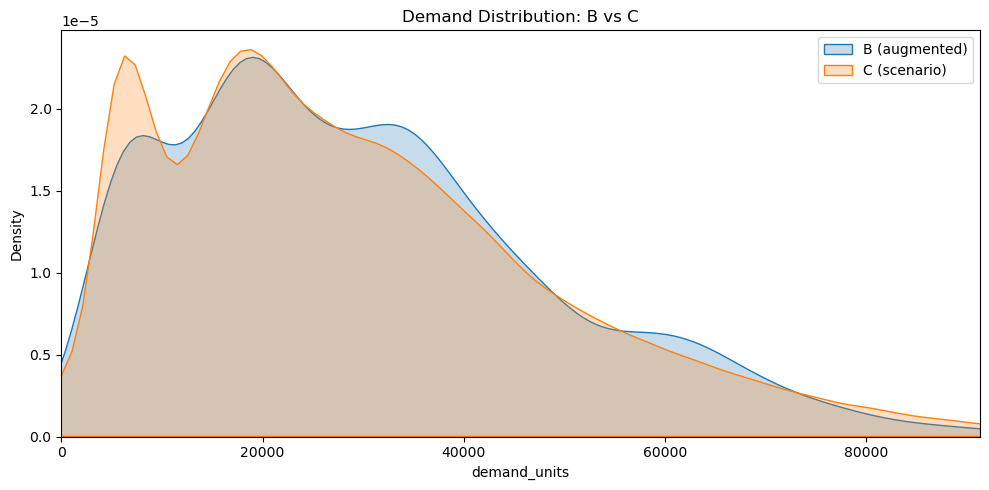

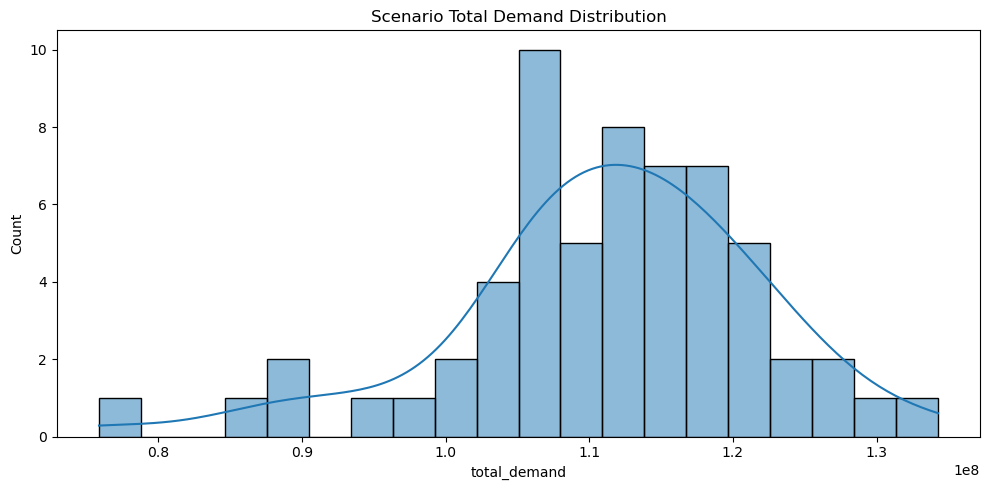

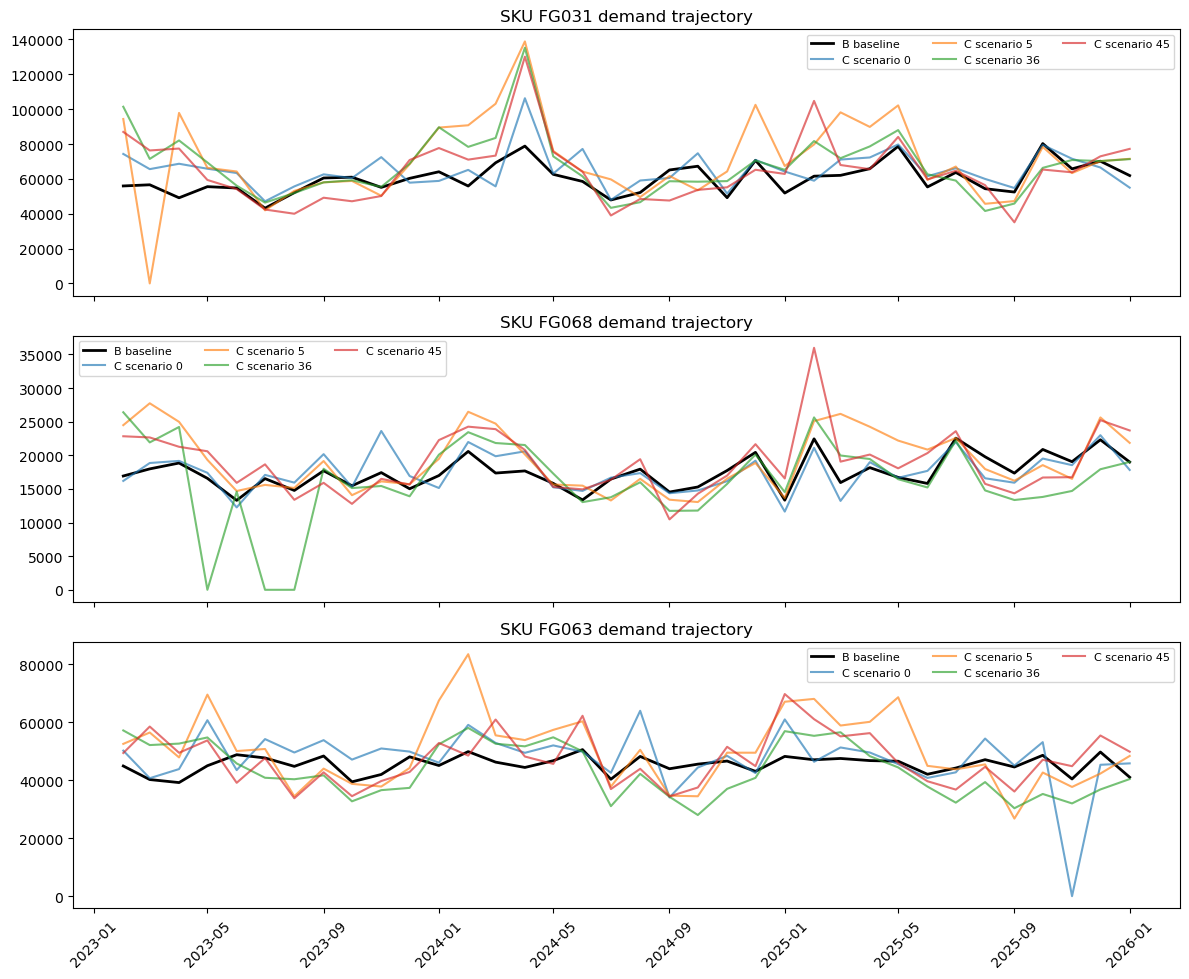

In [6]:
# =========================================
# BLOCK 6 — Scenario C Visualization (Deep EDA)
# =========================================

# If running standalone, load from exported file.
if "c_df" not in globals():
    c_df = pd.read_csv(OUT_CSV)
    c_df["month"] = pd.to_datetime(c_df["month"])

if "base" not in globals():
    base = pd.read_excel(BASE_AUG_PATH, sheet_name=BASE_SHEET)
    base["month"] = pd.to_datetime(base["month"])

print("C dataset shape:", c_df.shape)
print("Scenarios:", c_df["scenario_id"].nunique())
print("Split counts:")
print(c_df["scenario_split"].value_counts())

# 1) Demand distribution: base B vs C
plt.figure(figsize=(10, 5))
sns.kdeplot(base["demand_units"], label="B (augmented)", fill=True, alpha=0.25)
sns.kdeplot(c_df["demand_units"], label="C (scenario)", fill=True, alpha=0.25)
plt.title("Demand Distribution: B vs C")
plt.xlim(0, np.quantile(c_df["demand_units"], 0.99))
plt.legend()
plt.tight_layout()
plt.show()

# 2) Scenario-level total demand spread
sc_tot = c_df.groupby("scenario_id")["demand_units"].sum().reset_index(name="total_demand")
plt.figure(figsize=(10, 5))
sns.histplot(sc_tot["total_demand"], bins=20, kde=True)
plt.title("Scenario Total Demand Distribution")
plt.tight_layout()
plt.show()

# 3) Sample trajectories for a few SKUs across scenarios
sample_skus = c_df["fg_code"].drop_duplicates().sample(3, random_state=42).tolist()
sample_scen = sorted(c_df["scenario_id"].drop_duplicates().sample(4, random_state=42).tolist())

fig, axes = plt.subplots(len(sample_skus), 1, figsize=(12, 3.3 * len(sample_skus)), sharex=True)
if len(sample_skus) == 1:
    axes = [axes]

for ax, sku in zip(axes, sample_skus):
    b = base[base["fg_code"] == sku].sort_values("month")
    ax.plot(b["month"], b["demand_units"], color="black", linewidth=2, label="B baseline")
    for sid in sample_scen:
        s = c_df[(c_df["fg_code"] == sku) & (c_df["scenario_id"] == sid)].sort_values("month")
        ax.plot(s["month"], s["demand_units"], alpha=0.65, label=f"C scenario {sid}")
    ax.set_title(f"SKU {sku} demand trajectory")
    ax.legend(ncol=3, fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [7]:
# =========================================
# BLOCK 7 — Compatibility Checks (B vs C)
# =========================================

# Compare category shares
b_share = base.groupby("fg_category")["demand_units"].sum()
b_share = b_share / b_share.sum()

c_share = c_df.groupby("fg_category")["demand_units"].sum()
c_share = c_share / c_share.sum()

share_cmp = pd.concat([b_share.rename("B_share"), c_share.rename("C_share")], axis=1).fillna(0)
share_cmp["abs_diff_pp"] = (share_cmp["C_share"] - share_cmp["B_share"]).abs() * 100

print("Category share absolute difference (pp):")
print(share_cmp.sort_values("abs_diff_pp", ascending=False).round(3))

# Key percentiles comparison
def pct(s):
    return pd.Series({
        "p10": float(np.quantile(s, 0.10)),
        "p50": float(np.quantile(s, 0.50)),
        "p90": float(np.quantile(s, 0.90)),
        "mean": float(np.mean(s)),
    })

cmp = pd.DataFrame({
    "B": pct(base["demand_units"]),
    "C": pct(c_df["demand_units"]),
})
cmp["ratio_C_over_B"] = (cmp["C"] / cmp["B"]).round(3)
print("\nDemand percentile compatibility:")
print(cmp.round(2))

# Coverage checks
bal = c_df.groupby(["scenario_id", "fg_code"]).size()
print("\nPer (scenario, SKU) months min/max:", int(bal.min()), int(bal.max()))

# Practical compatibility gate
compatible = (
    bal.min() == bal.max() == base["month"].nunique()
    and cmp.loc["p50", "ratio_C_over_B"] >= 0.75
    and cmp.loc["p50", "ratio_C_over_B"] <= 1.35
)
print("Compatibility gate:", "PASS" if compatible else "CHECK")


Category share absolute difference (pp):
              B_share  C_share  abs_diff_pp
fg_category                                
Shampoo         0.207    0.205        0.217
Soap            0.255    0.256        0.132
Diaper          0.166    0.167        0.127
Lotion/Cream    0.073    0.074        0.071
Sanitary        0.078    0.078        0.063
Baby Care       0.025    0.025        0.038
Liquid Wash     0.089    0.089        0.033
Home Care       0.073    0.074        0.015
Combo           0.008    0.008        0.008
Talc            0.026    0.026        0.002

Demand percentile compatibility:
             B         C  ratio_C_over_B
p10    7047.00   6704.00            0.95
p50   26956.50  26170.00            0.97
p90   57840.20  58222.10            1.01
mean  29995.53  29988.53            1.00

Per (scenario, SKU) months min/max: 36 36
Compatibility gate: PASS


In [8]:
# =========================================
# BLOCK 8 — Cleaning C (Robust Outlier Capping)
# =========================================

# Clean within each (scenario_id, fg_code) trajectory to preserve scenario logic.

def cap_outliers_group(g, iqr_k=2.5):
    g = g.sort_values("month").copy()
    y = g["demand_units"].astype(float)

    q1, q3 = y.quantile(0.25), y.quantile(0.75)
    iqr = q3 - q1
    lo = max(0.0, q1 - iqr_k * iqr)
    hi = q3 + iqr_k * iqr

    is_out = ((y < lo) | (y > hi)).astype(int)
    y_clean = y.clip(lower=lo, upper=hi)

    g["c_is_outlier"] = is_out
    g["demand_units_clean"] = np.round(y_clean).astype(int)
    g["c_outlier_low"] = lo
    g["c_outlier_high"] = hi
    return g

c_clean = pd.concat(
    [cap_outliers_group(g) for _, g in c_df.groupby(["scenario_id", "fg_code"], sort=False)],
    ignore_index=True,
)

print("Rows:", len(c_clean))
print("Flagged outlier rows:", int(c_clean["c_is_outlier"].sum()))
print("Outlier rate (%):", round(100 * c_clean["c_is_outlier"].mean(), 3))

# Save cleaned Scenario C
C_CLEAN_CSV = "/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_scenario_c_dataset_cleaned.csv"
C_CLEAN_XLSX = "/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_scenario_c_dataset_cleaned.xlsx"

c_clean.to_csv(C_CLEAN_CSV, index=False)
with pd.ExcelWriter(C_CLEAN_XLSX, engine="openpyxl") as writer:
    c_clean.to_excel(writer, index=False, sheet_name="Scenario_C_Cleaned")

print("Saved cleaned C:")
print(C_CLEAN_CSV)
print(C_CLEAN_XLSX)


Rows: 222480
Flagged outlier rows: 2654
Outlier rate (%): 1.193
Saved cleaned C:
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_scenario_c_dataset_cleaned.csv
/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/Forecast model train data optiwms/hemas_scenario_c_dataset_cleaned.xlsx


In [9]:
# =========================================
# BLOCK 9 — C Readiness Checklist
# =========================================

req_cols = [
    "month", "fg_code", "fg_name", "fg_category", "demand_units_clean",
    "on_hand_inventory", "stockout_days", "promotion_flag", "price_or_discount",
    "lead_time_days", "supplier_otif", "inbound_po_qty", "open_sales_orders",
    "returns_qty", "holiday_flag", "scenario_id", "scenario_split"
]

checks = {}
checks["required_columns"] = all(c in c_clean.columns for c in req_cols)
checks["no_negative_target"] = bool((c_clean["demand_units_clean"] >= 0).all())
checks["no_duplicate_key"] = int(c_clean.duplicated(["scenario_id", "fg_code", "month"]).sum()) == 0
checks["valid_split_labels"] = set(c_clean["scenario_split"].unique()).issubset({"train", "test"})
checks["promo_binary"] = bool(c_clean["promotion_flag"].isin([0, 1]).all())
checks["holiday_binary"] = bool(c_clean["holiday_flag"].isin([0, 1]).all())
checks["otif_range"] = bool(c_clean["supplier_otif"].between(0, 1).all())
checks["train_test_both_present"] = set(c_clean["scenario_split"].unique()) == {"train", "test"}

# time-depth per trajectory
obs = c_clean.groupby(["scenario_id", "fg_code"]).size()
checks["balanced_months_per_sku_scenario"] = bool(obs.nunique() == 1)
checks["minimum_24_points"] = int(obs.min()) >= 24

for k, v in checks.items():
    print(f"{k}: {'PASS' if v else 'FAIL'}")

c_ready = all(checks.values())
print("\nScenario C training readiness:", "YES" if c_ready else "NO")

# Guidance note for leakage safety
print("Leakage rule: lag operational features by forecast horizon before model training.")


required_columns: PASS
no_negative_target: PASS
no_duplicate_key: PASS
valid_split_labels: PASS
promo_binary: PASS
holiday_binary: PASS
otif_range: PASS
train_test_both_present: PASS
balanced_months_per_sku_scenario: PASS
minimum_24_points: PASS

Scenario C training readiness: YES
Leakage rule: lag operational features by forecast horizon before model training.
